# Analiza gibanja svetovnih valut in cene zlata (2016-2025)

V tej analizi primerjamo mesečno gibanje 10 svetovnih valut proti evru (EUR) ter ceno zlata v obdobju od 2016 do 2025. Raziskujemo naslednja vprašanja:

- Katere valute so najbolj/najmanj volatilne (nestabilne), in kako se ta 
  nestabilnost spreminja skozi čas?
- Kako je pandemija covid-19 (2020) vplivala na valute in zlato - tako 
  kratkoročno kot v širšem obdobju?
- Ali obstaja povezava (korelacija) med cenami zlata in vrednostjo valut?
- Ali opazimo kakšne razlike med celinami?
- Kako bi bilo gibanje valut videti, če bi jih primerjali z drugo valuto 
  namesto z evrom?

In [151]:
import pandas as pd

# prebere osnovne podatke
valute = pd.read_csv("podatki/valute.csv")
zlato = pd.read_csv("podatki/zlato.csv")
drzave = pd.read_csv("podatki/drzave.csv")

# poveže valute z državami/celinami
valute = pd.merge(valute, drzave, on="valuta")

# ustvari en datum stolpec za lažje risanje grafov skozi cas
valute["datum"] = pd.to_datetime(valute["leto"].astype(str) + "-" + valute["mesec"].astype(str) + "-01")
zlato["datum"] = pd.to_datetime(zlato["leto"].astype(str) + "-" + zlato["mesec"].astype(str) + "-01")

valute.head()

,valuta,leto,mesec,menjalni_tecaj,drzava,celina,ime_valute,prebivalstvo,datum
0,AUD,2016,1,1.546290,Avstralija,Oceanija,Avstralski dolar,26.0,2016-01-01
1,AUD,2016,2,1.557452,Avstralija,Oceanija,Avstralski dolar,26.0,2016-02-01
2,AUD,2016,3,1.484574,Avstralija,Oceanija,Avstralski dolar,26.0,2016-03-01
3,AUD,2016,4,1.479791,Avstralija,Oceanija,Avstralski dolar,26.0,2016-04-01
4,AUD,2016,5,1.544764,Avstralija,Oceanija,Avstralski dolar,26.0,2016-05-01


## Volatilnost valut

Volatilnost pove, kako zelo tečaj valute niha skozi čas. Izračunamo jo kot 
standardni odklon mesečnih tečajev (večji odklon pomeni 
bolj nestabilno valuto).

In [152]:
volatilnost = valute.groupby(["valuta", "ime_valute"])["menjalni_tecaj"].std().sort_values(ascending=False)
volatilnost

valuta  ime_valute       
JPY     Japonski jen         17.765788
TRY     Turska lira          14.023828
ZAR     Juznoafriski rand     1.979209
BRL     Brazilski real        1.014545
CNY     Kitajski juan         0.323826
AUD     Avstralski dolar      0.088676
CHF     Svicarski frank       0.075136
CAD     Kanadski dolar        0.062009
USD     Ameriski dolar        0.053133
GBP     Britanski funt        0.028194
Name: menjalni_tecaj, dtype: float64

Zdi se, kot da je japonski jen (JPY) najbolj volatilna valuta. To ni res, valute imajo namreč različne vrednosti. Pravilno rešitev dobimo tako, da izračunamo standardni odklon mesečnih sprememb v odstotkih, saj je to neodvisno vrednosti ene enote določene valute.

In [153]:
valute = valute.sort_values(["valuta", "datum"])
valute["mesecna_sprememba"] = valute.groupby("valuta")["menjalni_tecaj"].pct_change() * 100

volatilnost_pravilna = valute.groupby(["valuta", "ime_valute"])["mesecna_sprememba"].std().sort_values(ascending=False)
volatilnost_pravilna

valuta  ime_valute       
TRY     Turska lira          4.676695
BRL     Brazilski real       3.270584
ZAR     Juznoafriski rand    3.016953
AUD     Avstralski dolar     1.910154
JPY     Japonski jen         1.801504
USD     Ameriski dolar       1.593299
CAD     Kanadski dolar       1.572150
GBP     Britanski funt       1.551909
CNY     Kitajski juan        1.373985
CHF     Svicarski frank      1.057917
Name: mesecna_sprememba, dtype: float64

Rezultate volatilnosti si poglejmo tudi grafično, da bo razmerje med valutami lažje razbrati.

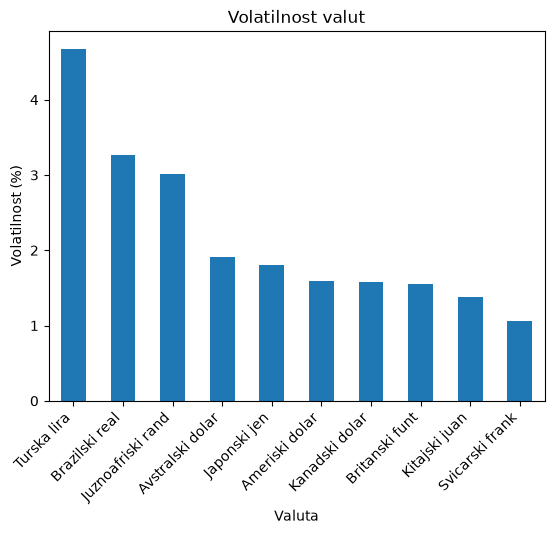

In [154]:
import matplotlib.pyplot as plt

graf_podatki = volatilnost_pravilna.reset_index()

graf_podatki.plot.bar(x="ime_valute", y="mesecna_sprememba", legend=False)
plt.title("Volatilnost valut")
plt.ylabel("Volatilnost (%)")
plt.xlabel("Valuta")
plt.xticks(rotation=45, ha="right")
plt.show()

Vidimo, da daleč najbolj volatilna valouta je turška lira, svicarski frank pa je najbolj stabilen.

## Vpliv pandemije covid-19 (2020)

Marca 2020 so finančni trgi doživeli enega največjih šokov v zadnjih 
desetletjih. Poglejmo, kako se je to odrazilo na naših valutah in ceni 
zlata. Najprej si bomo ogledali širšo sliko skozi čas (2019-2020), nato 
pa natančno izmerili, kako drastičen je bil dejanski šok v prvih mesecih 
pandemije.

**Opomba glede metodologije:** Ker vse valute merimo proti EUR, tudi gibanje samega EUR močno upliva na na vse ostale valute.
proti vsem valutam, bo to na grafu videti kot da so vse ostale valute.
Ampak to uresnici ni velik problem saj deluje nihanje EUR na vse ostale valute priblizno enako tako da nam relativne razlike ostalih podatkov se vedno lahko veliko povejo.

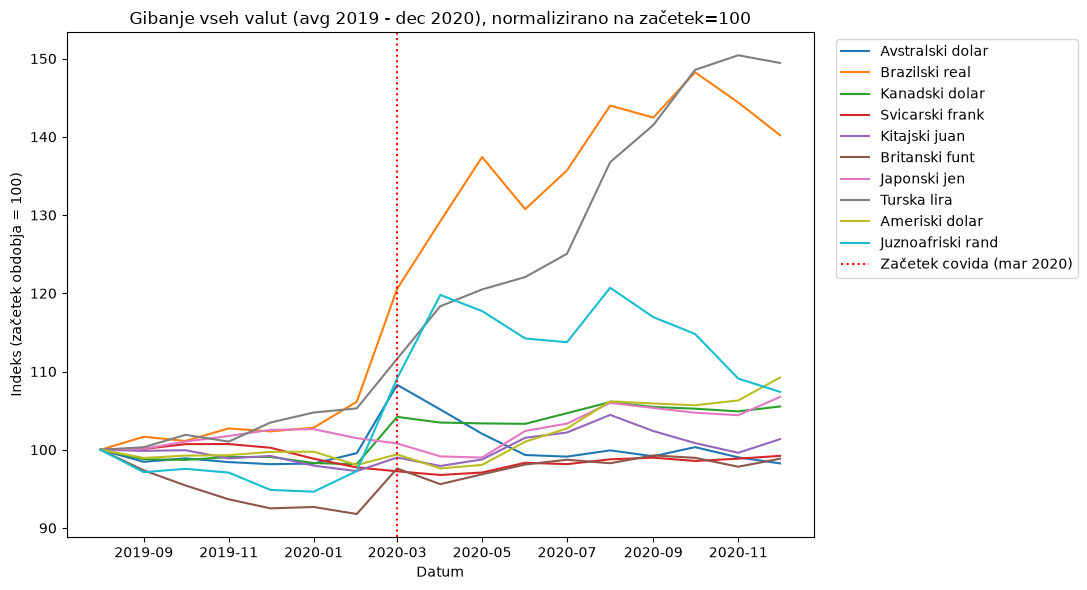

In [276]:
zacetek = "2019-08-01"
konec = "2020-12-01"

obdobje_valute = valute[(valute.datum >= zacetek) & (valute.datum <= konec)]

plt.figure(figsize=(11, 6))
for valuta in valute.valuta.unique():
    podatki_valute = obdobje_valute[obdobje_valute.valuta == valuta].sort_values("datum")
    zacetna_vrednost = list(podatki_valute.menjalni_tecaj)[0]
    normalizirano = podatki_valute.menjalni_tecaj / zacetna_vrednost * 100
    ime = list(podatki_valute.ime_valute)[0]
    plt.plot(podatki_valute.datum, normalizirano, label=ime)

plt.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle=":", label="Začetek covida (mar 2020)")
plt.title("Gibanje vseh valut (avg 2019 - dec 2020), normalizirano na začetek=100")
plt.ylabel("Indeks (začetek obdobja = 100)")
plt.xlabel("Datum")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Vidimo, da je kar nekaj valut izgubilo zelo hitro zelo veliko vrednosti proti EUR. Da bomo bolje
razumeli stvar pa časovno še zmanšajmo na 4 mesece in pretvorimo graf v stopični diagram.

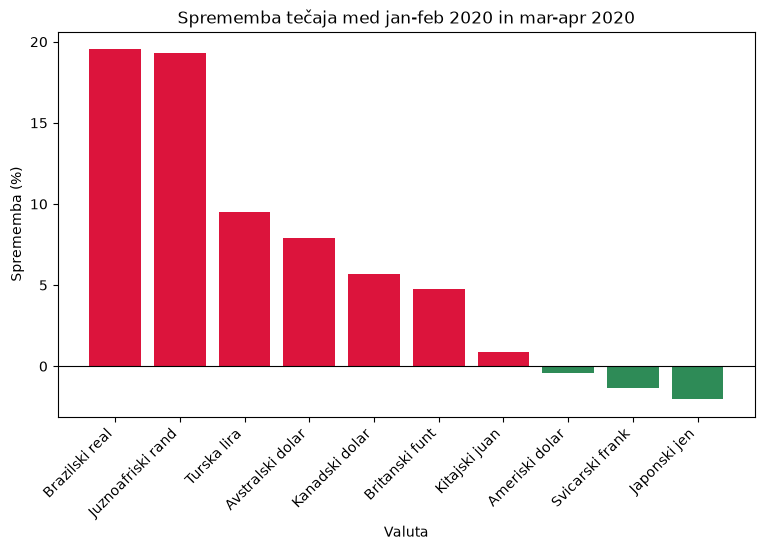

In [277]:

pred_covidom = valute[(valute.leto == 2020) & (valute.mesec.isin([1, 2]))]
med_covidom = valute[(valute.leto == 2020) & (valute.mesec.isin([3, 4]))]

povprecje_pred = pred_covidom.groupby(["valuta", "ime_valute"])["menjalni_tecaj"].mean()
povprecje_med = med_covidom.groupby(["valuta", "ime_valute"])["menjalni_tecaj"].mean()

sprememba_covid = ((povprecje_med - povprecje_pred) / povprecje_pred * 100).sort_values(ascending=False)

graf_sprememba = sprememba_covid.reset_index()
barve = ["crimson" if x > 0 else "seagreen" for x in graf_sprememba.menjalni_tecaj]

plt.figure(figsize=(9, 5))
plt.bar(graf_sprememba.ime_valute, graf_sprememba.menjalni_tecaj, color=barve)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Sprememba tečaja med jan-feb 2020 in mar-apr 2020")
plt.ylabel("Sprememba (%)")
plt.xlabel("Valuta")
plt.xticks(rotation=45, ha="right")
plt.show()

Sedaj pa lepo vidimo, katere valute so covid šok uspešno prekoračile in katere ne.

## Korelacija med zlatom in valutami

Zanima nas, ali obstaja povezava med gibanjem cene zlata in vrednostjo 
posameznih valut. Če je zlato res "varno pristanišče", bi pričakovali, da 
ko rizične valute slabijo (padajo), cena zlata raste, torej negativno 
korelacijo.

In [278]:
# izracunamo mesecno spremembo cene zlata
zlato = zlato.sort_values("datum")
zlato["sprememba_zlata"] = zlato["cena_zlata"].pct_change() * 100

# povezemo valute (z mesecno spremembo) z zlatom, po letu in mesecu
valute_zlato = pd.merge(valute, zlato[["leto", "mesec", "sprememba_zlata"]], on=["leto", "mesec"])

korelacije = valute_zlato.groupby(["valuta", "ime_valute"]).apply(
    lambda skupina: skupina["mesecna_sprememba"].corr(skupina["sprememba_zlata"])
).sort_values()

korelacije

valuta  ime_valute       
JPY     Japonski jen        -0.190941
TRY     Turska lira         -0.087886
AUD     Avstralski dolar    -0.062558
BRL     Brazilski real      -0.049911
ZAR     Juznoafriski rand    0.009053
CHF     Svicarski frank      0.012026
GBP     Britanski funt       0.124746
CAD     Kanadski dolar       0.142013
CNY     Kitajski juan        0.154439
USD     Ameriski dolar       0.410010
dtype: float64

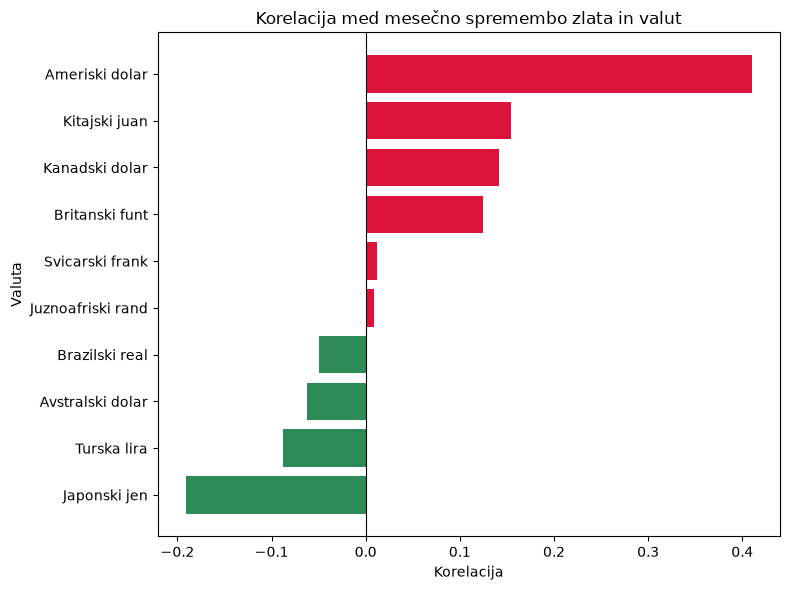

In [279]:
graf_korelacije = korelacije.reset_index()
graf_korelacije.columns = ["valuta", "ime_valute", "korelacija"]

barve = ["seagreen" if x < 0 else "crimson" for x in graf_korelacije.korelacija]

plt.figure(figsize=(8, 6))
plt.barh(graf_korelacije.ime_valute, graf_korelacije.korelacija, color=barve)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelacija med mesečno spremembo zlata in valut")
plt.xlabel("Korelacija")
plt.ylabel("Valuta")
plt.tight_layout()
plt.show()

Graf nam nepokaže negativne korelacije z valutami, mogoce celo prav nasprotno.
Ampak še vseno poglejmo podrobneje to negaticno korelacijo med JPY in zlatom 
z malo drugačnim grafom, kjer vsaka poka predstavlja en mesec.

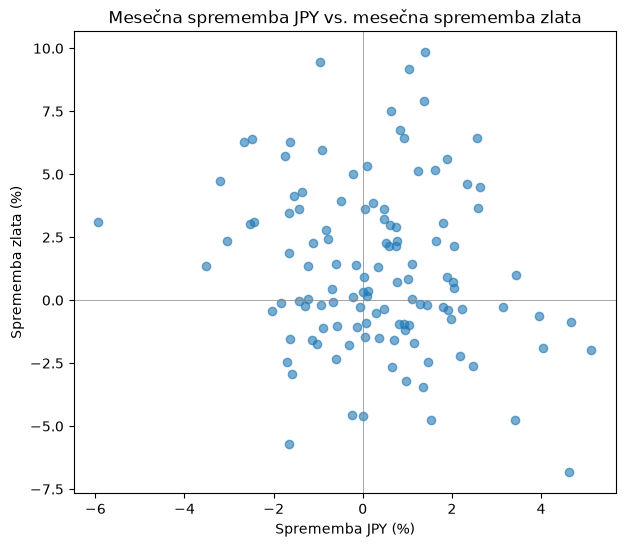

In [280]:
jpy_podatki = valute_zlato[valute_zlato.valuta == "JPY"]

plt.figure(figsize=(7, 6))
plt.scatter(jpy_podatki.mesecna_sprememba, jpy_podatki.sprememba_zlata, alpha=0.6)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Mesečna sprememba JPY vs. mesečna sprememba zlata")
plt.xlabel("Sprememba JPY (%)")
plt.ylabel("Sprememba zlata (%)")
plt.show()

Če bi bila ta korelacija bolj negativna, bi pričakovali, da bi se pike zgostile okoli 
simetrale lihih kvadrantov, ker pa ni moramo kar zelo pomižikniti, da kaj takega v grafu opazimo. Poglejmo še korelacijo med USD in zlatom.

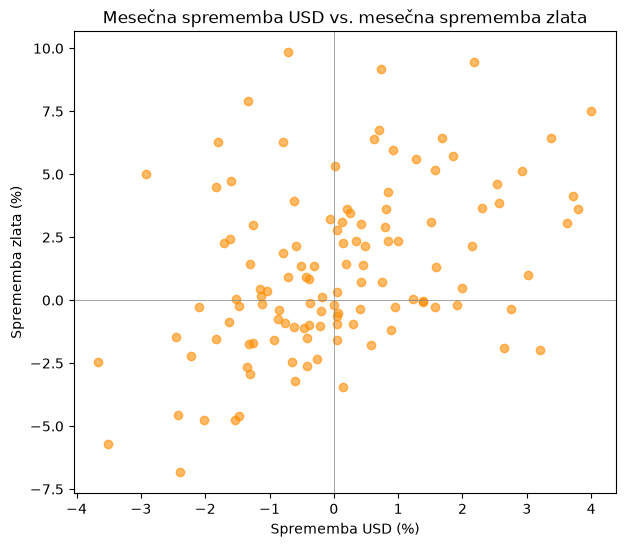

In [281]:
usd_podatki = valute_zlato[valute_zlato.valuta == "USD"]

plt.figure(figsize=(7, 6))
plt.scatter(usd_podatki.mesecna_sprememba, usd_podatki.sprememba_zlata, alpha=0.6, color="darkorange")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Mesečna sprememba USD vs. mesečna sprememba zlata")
plt.xlabel("Sprememba USD (%)")
plt.ylabel("Sprememba zlata (%)")
plt.show()

Tu pa se veliko lepše vidi, kako se pike bolj zgostijo okoli simerale lihih kvadrantov.

## Primerjava volatilnosti po celinah

Zanima nas, ali obstajajo razlike v volatilnosti valut glede na celino, iz 
katere prihajajo. Pričakujemo, da bodo valute iz razvitih gospodarstev 
(Evropa, Severna Amerika) v povprečju stabilnejše od valut iz gospodarstev 
v razvoju.

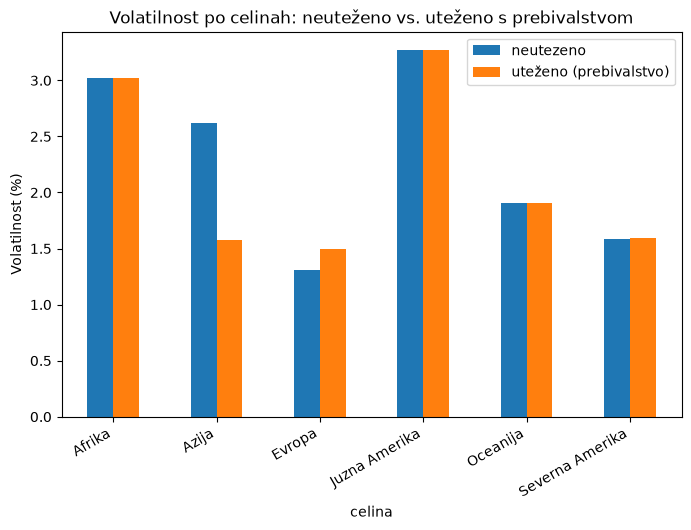

In [282]:
volatilnost_valut = valute.groupby(["valuta", "celina", "prebivalstvo"])["mesecna_sprememba"].std().reset_index()

neutezeno = volatilnost_valut.groupby("celina")["mesecna_sprememba"].mean()
utezeno = volatilnost_valut.groupby("celina").apply(
    lambda g: (g["mesecna_sprememba"] * g["prebivalstvo"]).sum() / g["prebivalstvo"].sum()
)

primerjava = pd.DataFrame({"neutezeno": neutezeno, "uteženo (prebivalstvo)": utezeno})
primerjava.plot.bar(figsize=(8, 5))
plt.title("Volatilnost po celinah: neuteženo vs. uteženo s prebivalstvom")
plt.ylabel("Volatilnost (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

Tu sem poskusil primerjati volatilnost, valut glede na to kje na zemlji se te valute nahajajo.
Rezultat ni prav koristen, saj sem za kaj tekega vzel čisto premalo valut. Uteženost s prebivalstvom pa sem dodal, saj je še posebej turška lira močno izravnotežila volatilnost svoje celine. Prebivalstvo, tudi zdaleč ni edini faktor, ki bi ga bilo treba obravnavati če bi hoteli resnično izračunati povprečno volatilnost celin.

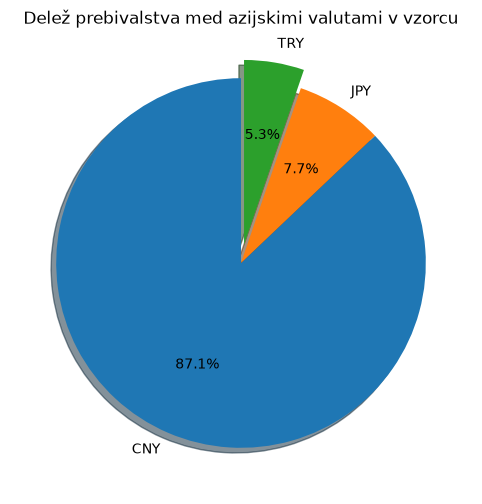

In [283]:
azija = volatilnost_valut[volatilnost_valut.celina == "Azija"].copy()

razmik_prebivalstvo = [0.1 if valuta == "TRY" else 0 for valuta in azija["valuta"]]

plt.figure(figsize=(6, 6))
plt.pie(azija["prebivalstvo"], labels=azija["valuta"], autopct="%1.1f%%",
        explode=razmik_prebivalstvo, shadow=True, startangle=90)
plt.title("Delež prebivalstva med azijskimi valutami v vzorcu")
plt.show()

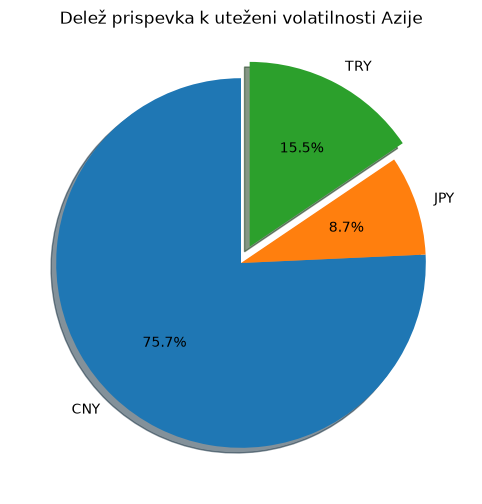

In [284]:
azija["prispevek"] = azija["mesecna_sprememba"] * azija["prebivalstvo"]

razmik_prispevek = [0.1 if valuta == "TRY" else 0 for valuta in azija["valuta"]]

plt.figure(figsize=(6, 6))
plt.pie(azija["prispevek"], labels=azija["valuta"], autopct="%1.1f%%",
        explode=razmik_prispevek, shadow=True, startangle=90)
plt.title("Delež prispevka k uteženi volatilnosti Azije")
plt.show()

Tu sta še tortna diagrama, ki pokažeta kako dodatek prebivalstva spremeni volatilnost  Azije.10

## Celotno 10-letno obdobje in pogled iz drugih valut

Zdaj ko smo videli vse te podatke, si poglejmo graf vseh desetih valut za 
celotno obdobje 2016-2025. Zaradi ogromnih razlik v obsegu uporabimo logaritemsko skalo na y-osi.

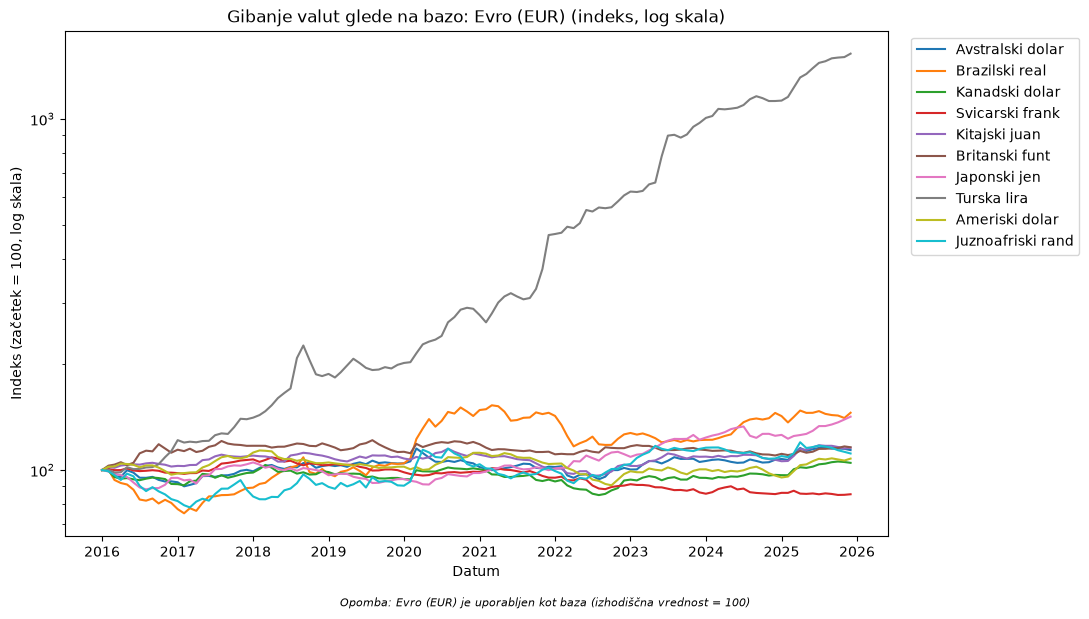

In [285]:
pivot = valute.pivot_table(index="datum", columns="valuta", values="menjalni_tecaj")

ime_slovar = dict(zip(drzave["valuta"], drzave["ime_valute"]))
#Nariše gibanje vseh valut (+ EUR) glede na poljubno izbrano bazno valuto
def narisi_prebazirano(baza):
    
    if baza == "EUR":
        prebazirano = pivot.copy()
        prebazirano["EUR"] = 1.0
    else:
        prebazirano = pivot.div(pivot[baza], axis=0)
        prebazirano["EUR"] = 1 / pivot[baza]

    plt.figure(figsize=(11, 6))
    for valuta in prebazirano.columns:
        if valuta == baza:
            continue
        normalizirano = prebazirano[valuta] / list(prebazirano[valuta])[0] * 100
        plt.plot(prebazirano.index, normalizirano, label=ime_slovar.get(valuta, valuta))

    ime_baze = ime_slovar.get(baza, baza)
    plt.yscale("log")
    plt.title(f"Gibanje valut glede na bazo: {ime_baze} ({baza}) (indeks, log skala)")
    plt.ylabel("Indeks (začetek = 100, log skala)")
    plt.xlabel("Datum")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.figtext(0.5, -0.02, f"Opomba: {ime_baze} ({baza}) je uporabljen kot baza (izhodiščna vrednost = 100)",
                ha="center", fontsize=8, style="italic")
    plt.tight_layout()
    plt.show()

narisi_prebazirano("EUR")

Vidimo, da v desetih letih za nakup enako število EUR bi potrebovali več kot 10-krat več turške
lire. Drugače povedano turška lira je v zadnjem desetletju izgubila več kot 90% procentov svoje vrednosti. 

Poglejmo še kako, bi ta isti graf izgledal, če bi za bazo uzeli kakšno drugo valuto. Ali se veliko spremeni? Zakaj ne?

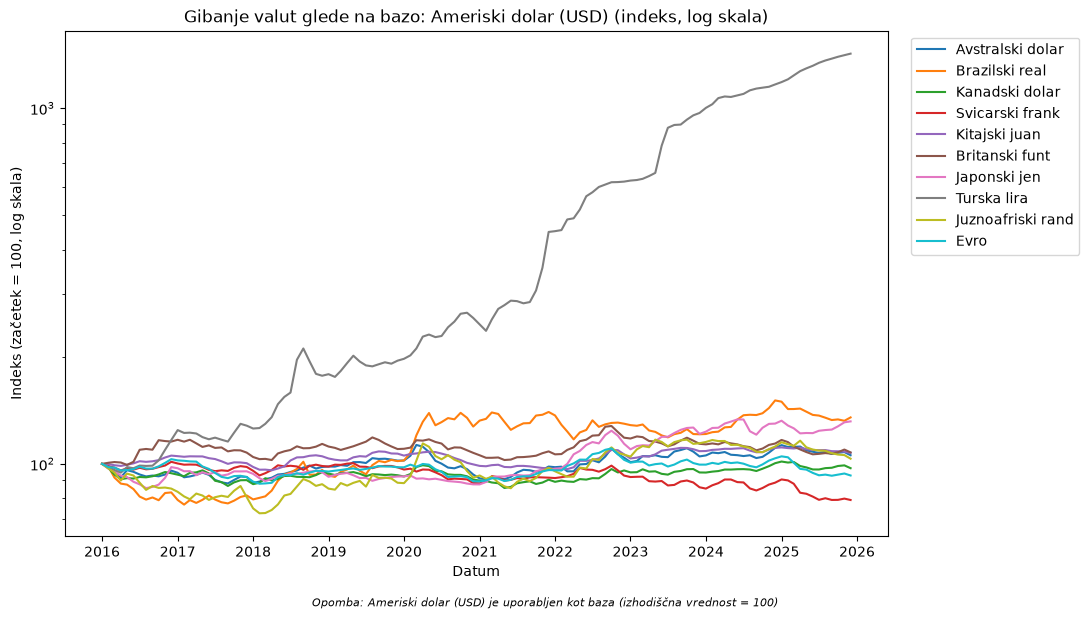

In [286]:
narisi_prebazirano("USD")

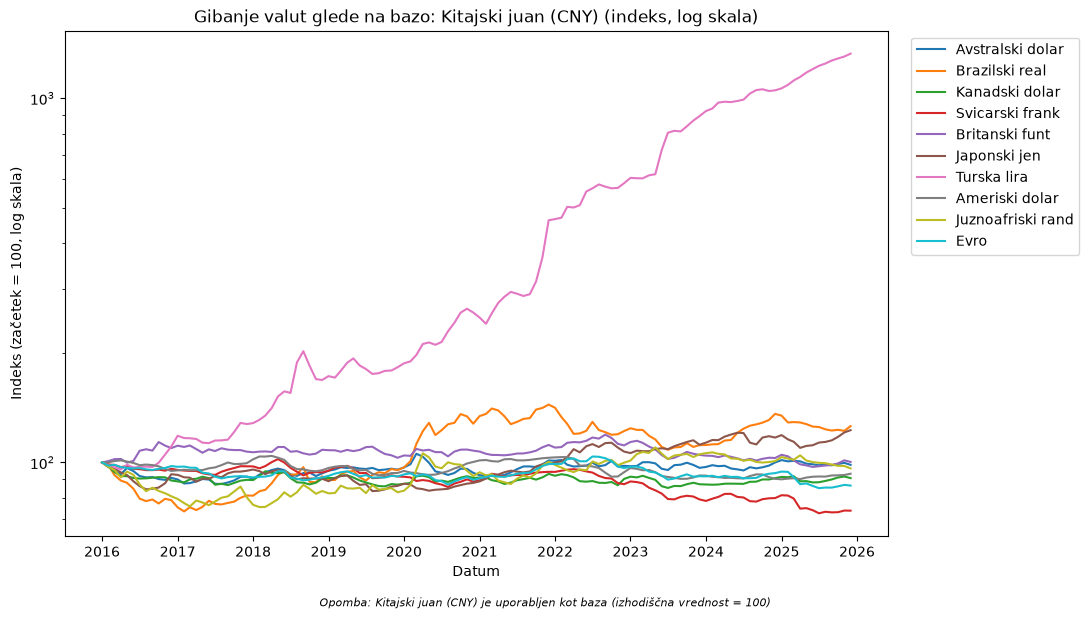

In [287]:
narisi_prebazirano("CNY")

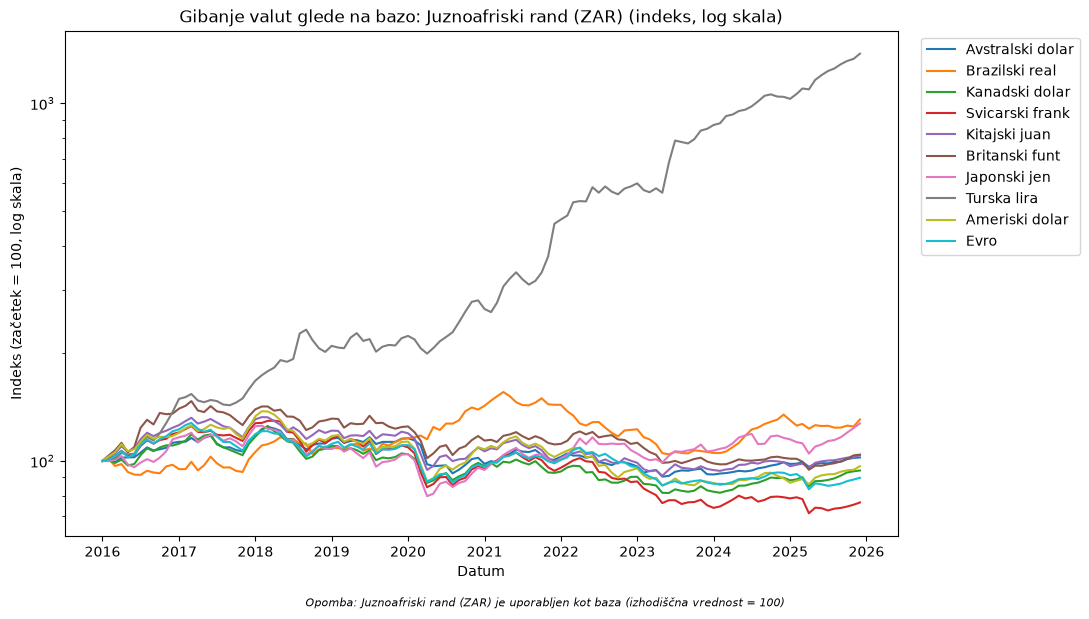

In [288]:
narisi_prebazirano("ZAR")

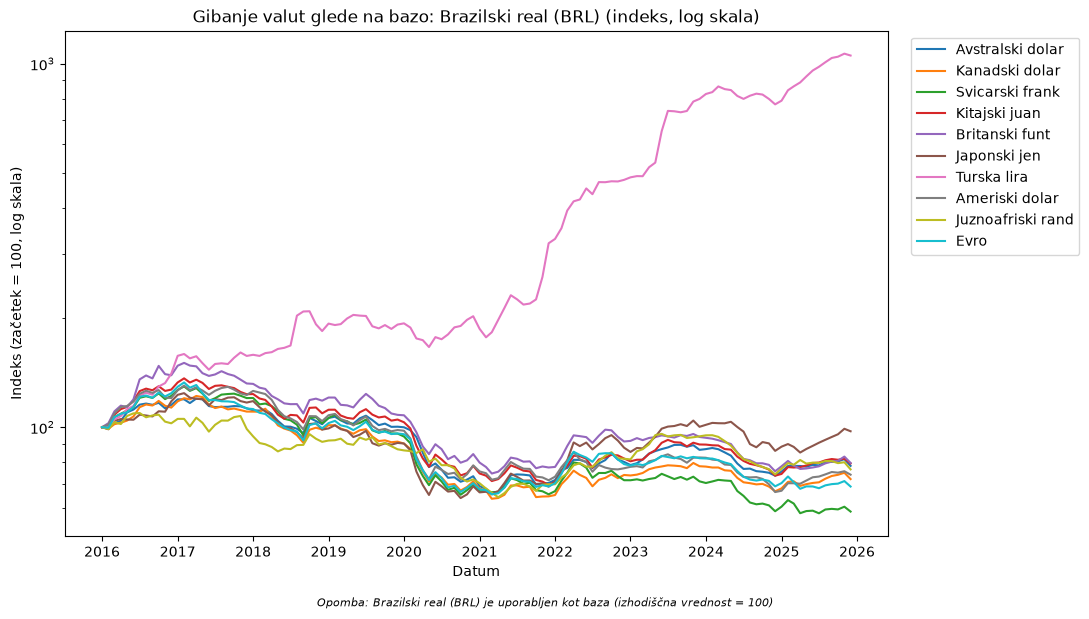

In [289]:
narisi_prebazirano("BRL")

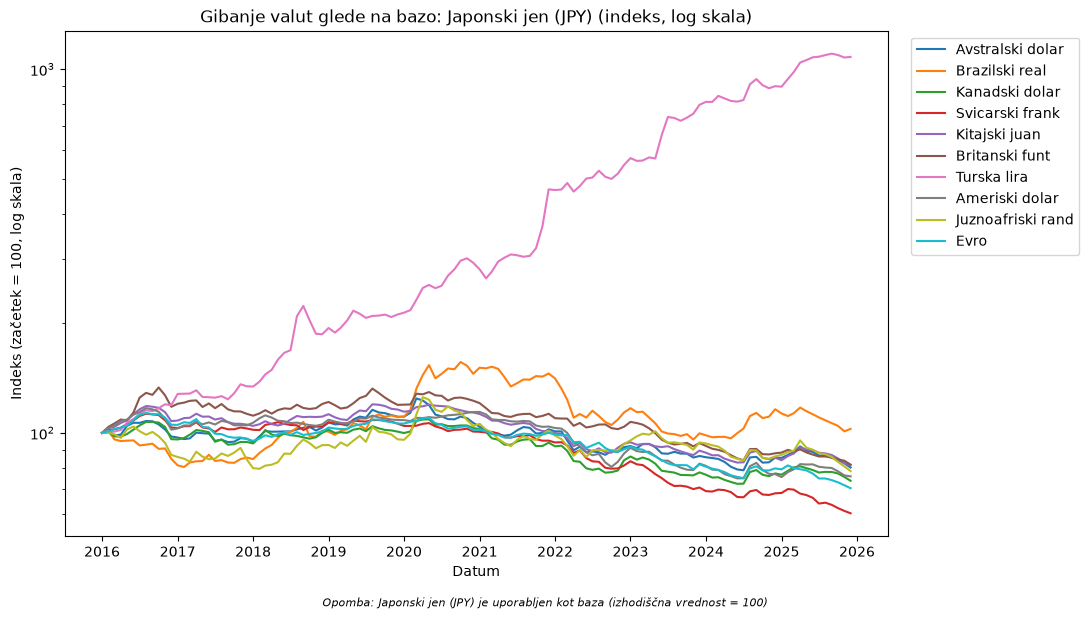

In [290]:
narisi_prebazirano("JPY")

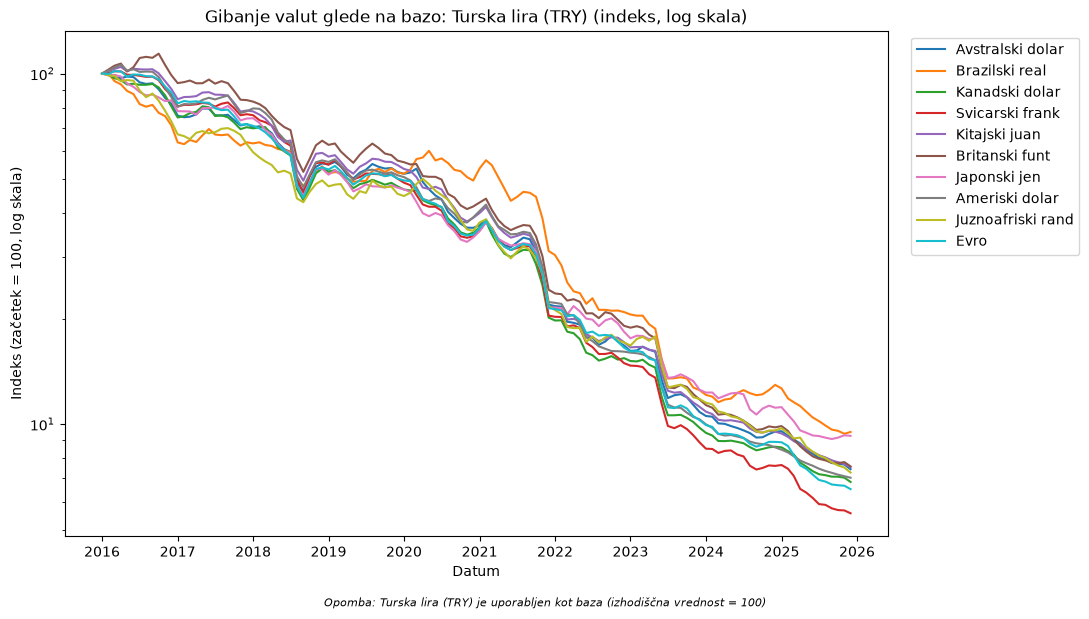

In [291]:
narisi_prebazirano("TRY")

## Volatilnost skozi čas

Prejšnja analiza volatilnosti je dala samo eno število za celotno desetletje.
kar skriva, ali je bila valuta ves čas enako nestabilna, ali je imela obdobja 
mirovanja in obdobja turbulence. Poglejmo si gibljivo (rolling) volatilnost sepravi
standardni odklon nebomo računali z vsemi podatki naenkrat ampak le z podatki iz zadnjih 
12-tih mesecev.

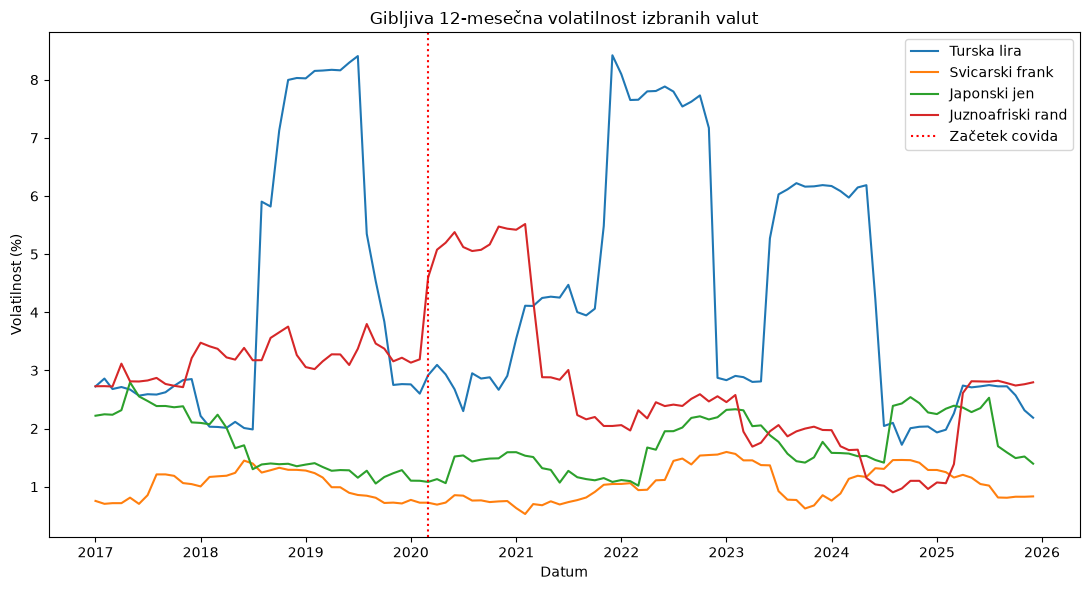

In [298]:
izbrane_valute_vol = ["TRY", "CHF", "JPY", "ZAR"]

plt.figure(figsize=(11, 6))
for valuta in izbrane_valute_vol:
    podatki = valute[valute.valuta == valuta].sort_values("datum")
    gibljiva_volatilnost = podatki["mesecna_sprememba"].rolling(window=12).std()
    plt.plot(podatki["datum"], gibljiva_volatilnost, label=ime_slovar.get(valuta, valuta))

plt.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle=":", label="Začetek covida")
plt.title("Gibljiva 12-mesečna volatilnost izbranih valut")
plt.ylabel("Volatilnost (%)")
plt.xlabel("Datum")
plt.legend()
plt.tight_layout()
plt.show()

Graf razkrije zelo zanimive rezultate, še posebej za turško liro lahko vidimo da volatilnost je
tu daleč od konstante temveč prihaja v valovih odgovora zakaj pa tako je pa nimam.

## Kaj to pomeni v resničnih številkah?

Skozi celotno analizo smo se osredotočali na relativne spremembe (indeks, 
odstotki), ki so uporabni za primerjavo med valutami različnih velikosti. 
Poglejmo si zdaj tudi surove, dejanske vrednosti sepravi koliko posamezne valute dejansko dobimo za 1 EUR.

In [299]:
zadnje_vrednosti = valute.sort_values("datum").groupby(["valuta", "ime_valute"]).tail(1)
zadnje_vrednosti = zadnje_vrednosti[["ime_valute", "valuta", "menjalni_tecaj", "datum"]].sort_values("ime_valute")
zadnje_vrednosti.columns = ["Valuta", "Kratica", "1 EUR =", "Datum"]
zadnje_vrednosti

,Valuta,Kratica,1 EUR =,Datum
1079,Ameriski dolar,USD,1.171199,2025-12-01
119,Avstralski dolar,AUD,1.762742,2025-12-01
239,Brazilski real,BRL,6.396172,2025-12-01
719,Britanski funt,GBP,0.874873,2025-12-01
839,Japonski jen,JPY,182.710027,2025-12-01
1199,Juznoafriski rand,ZAR,19.721295,2025-12-01
359,Kanadski dolar,CAD,1.615446,2025-12-01
599,Kitajski juan,CNY,8.253057,2025-12-01
479,Svicarski frank,CHF,0.932990,2025-12-01
959,Turska lira,TRY,50.015965,2025-12-01


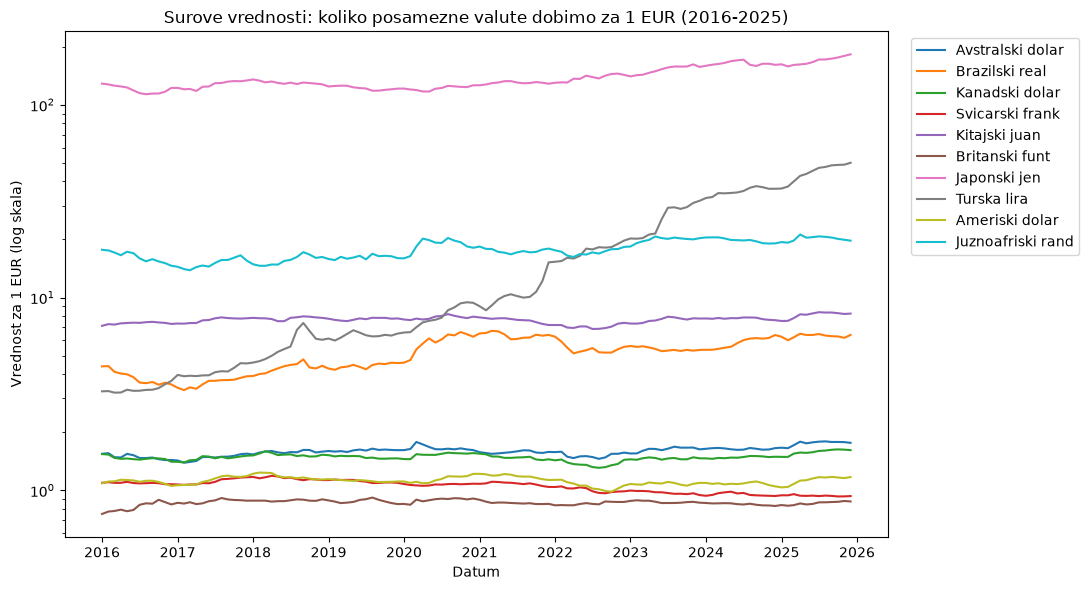

In [300]:
plt.figure(figsize=(11, 6))

for valuta in valute.valuta.unique():
    podatki_valute = valute[valute.valuta == valuta].sort_values("datum")
    ime = podatki_valute.ime_valute.iloc[0]
    plt.plot(podatki_valute["datum"], podatki_valute["menjalni_tecaj"], label=ime)

plt.yscale("log")
plt.title("Surove vrednosti: koliko posamezne valute dobimo za 1 EUR (2016-2025)")
plt.ylabel("Vrednost za 1 EUR (log skala)")
plt.xlabel("Datum")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Tudi ta graf pokaže, da so bile valute več ali manj stabilne glede na EUR, razn seveda turke lire.